# ParaView block summary

Read Akantu/ParaView `.pvtu` / `.vtu` files with PyVista, label connected blocks with VTK, and summarize displacement, stress, and other fields with pandas.

In [1]:
from pathlib import Path
import os
import re

# Avoid matplotlib cache warnings if the home config directory is not writable.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import pyvista as pv
import vtk

BUILD_DIR = Path.cwd()
if not (BUILD_DIR / "paraview").exists():
    BUILD_DIR = Path("/home/xinyuan/myakantu/akantu-playground/build")

PARAVIEW_DIR = BUILD_DIR / "paraview"
PATTERN = "bloc_friction_test1_*.pvtu"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

print("PyVista", pv.__version__)
print("VTK", vtk.vtkVersion.GetVTKVersion())
print("build dir:", BUILD_DIR)

PyVista 0.48.4
VTK 9.6.2
build dir: /home/xinyuan/myakantu/akantu-playground/build


## Helpers

In [2]:
def timestep_number(path):
    match = re.search(r"_(\d+)\.p?vtu$", Path(path).name)
    return int(match.group(1)) if match else -1


def latest_file(directory=PARAVIEW_DIR, pattern=PATTERN):
    files = sorted(Path(directory).glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files match {Path(directory) / pattern}")
    return max(files, key=timestep_number)


def read_connected_grid(path):
    """Read a VTU/PVTU file and add RegionId arrays for connected blocks."""
    grid = pv.read(path)

    connectivity = vtk.vtkConnectivityFilter()
    connectivity.SetInputData(grid)
    connectivity.SetExtractionModeToAllRegions()
    connectivity.ColorRegionsOn()
    connectivity.Update()

    connected = pv.wrap(connectivity.GetOutput())
    return connected


def array_stats(values, prefix):
    """Return mean/min/max columns for a scalar or vector/tensor array."""
    values = np.asarray(values)
    if values.ndim == 1:
        values = values[:, None]

    stats = {}
    for component in range(values.shape[1]):
        data = values[:, component]
        stats[f"{prefix}.c{component}.mean"] = float(np.mean(data))
        stats[f"{prefix}.c{component}.min"] = float(np.min(data))
        stats[f"{prefix}.c{component}.max"] = float(np.max(data))

    if values.shape[1] > 1:
        norm = np.linalg.norm(values, axis=1)
        stats[f"{prefix}.norm.mean"] = float(np.mean(norm))
        stats[f"{prefix}.norm.min"] = float(np.min(norm))
        stats[f"{prefix}.norm.max"] = float(np.max(norm))

    return stats


def summarize_blocks(grid, point_fields=None, cell_fields=None):
    """Summarize selected point and cell fields per connected block."""
    if "RegionId" not in grid.cell_data:
        raise ValueError("Grid has no cell RegionId. Use read_connected_grid(path).")

    point_region = np.asarray(grid.point_data["RegionId"])
    cell_region = np.asarray(grid.cell_data["RegionId"])
    region_ids = sorted(np.unique(cell_region).tolist())

    if point_fields is None:
        point_fields = [name for name in grid.point_data.keys() if name != "RegionId"]
    if cell_fields is None:
        cell_fields = [name for name in grid.cell_data.keys() if name != "RegionId"]

    rows = []
    for region_id in region_ids:
        point_mask = point_region == region_id
        cell_mask = cell_region == region_id

        row = {
            "block": int(region_id),
            "n_points": int(np.sum(point_mask)),
            "n_cells": int(np.sum(cell_mask)),
        }

        for field in point_fields:
            row.update(array_stats(grid.point_data[field][point_mask], field))

        for field in cell_fields:
            row.update(array_stats(grid.cell_data[field][cell_mask], field))

        rows.append(row)

    return pd.DataFrame(rows).sort_values("block").reset_index(drop=True)


def stress_with_names(summary):
    """Add convenient aliases for the four 2D stress components."""
    renamed = summary.copy()
    aliases = {
        "stress.c0.mean": "stress.xx.mean",
        "stress.c1.mean": "stress.yy.mean",
        "stress.c2.mean": "stress.xy.mean",
        "stress.c3.mean": "stress.zz_or_extra.mean",
    }
    for source, target in aliases.items():
        if source in renamed:
            renamed[target] = renamed[source]
    return renamed

## Latest timestep

In [3]:
path = latest_file()
grid = read_connected_grid(path)

print("file:", path)
print("points:", grid.n_points)
print("cells:", grid.n_cells)
print("point fields:", list(grid.point_data.keys()))
print("cell fields:", list(grid.cell_data.keys()))
print("blocks:", sorted(np.unique(grid.cell_data["RegionId"]).tolist()))

file: /home/xinyuan/myakantu/akantu-playground/build/paraview/bloc_friction_test1_0220.pvtu
points: 9495
cells: 18298
point fields: ['areas', 'blocked_dofs', 'contact_force', 'displacement', 'external_force', 'internal_force', 'normals', 'tangents', 'velocity', 'RegionId']
cell fields: ['stress', 'RegionId']
blocks: [0, 1]


In [4]:
summary = summarize_blocks(
    grid,
    point_fields=["displacement", "velocity", "contact_force", "external_force", "internal_force"],
    cell_fields=["stress"],
)

interesting_columns = [
    "block", "n_cells", "n_points",
    "displacement.c0.mean", "displacement.c1.mean", "displacement.c2.mean", "displacement.norm.mean",
    "stress.c0.mean", "stress.c1.mean", "stress.c2.mean", "stress.c3.mean", "stress.norm.mean",
]
summary[[column for column in interesting_columns if column in summary.columns]]

,block,n_cells,n_points,displacement.c0.mean,displacement.c1.mean,displacement.c2.mean,displacement.norm.mean,stress.c0.mean,stress.c1.mean,stress.c2.mean,stress.c3.mean,stress.norm.mean
0,0,16370,8365,9.984094,-0.562507,0.0,10.003423,-3.702767e+09,1.051441e+09,1.051441e+09,-3.675645e+10,3.889885e+10
1,1,1928,1130,0.000000,0.000000,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [5]:
summary_named = stress_with_names(summary)
summary_named.to_csv(BUILD_DIR / "block_summary_latest.csv", index=False)
summary_named

,block,n_points,n_cells,displacement.c0.mean,displacement.c0.min,displacement.c0.max,displacement.c1.mean,displacement.c1.min,displacement.c1.max,displacement.c2.mean,displacement.c2.min,displacement.c2.max,displacement.norm.mean,displacement.norm.min,displacement.norm.max,velocity.c0.mean,velocity.c0.min,velocity.c0.max,velocity.c1.mean,velocity.c1.min,velocity.c1.max,velocity.c2.mean,velocity.c2.min,velocity.c2.max,velocity.norm.mean,velocity.norm.min,velocity.norm.max,contact_force.c0.mean,contact_force.c0.min,contact_force.c0.max,contact_force.c1.mean,contact_force.c1.min,contact_force.c1.max,contact_force.c2.mean,contact_force.c2.min,contact_force.c2.max,contact_force.norm.mean,contact_force.norm.min,contact_force.norm.max,external_force.c0.mean,...,external_force.c1.mean,external_force.c1.min,external_force.c1.max,external_force.c2.mean,external_force.c2.min,external_force.c2.max,external_force.norm.mean,external_force.norm.min,external_force.norm.max,internal_force.c0.mean,internal_force.c0.min,internal_force.c0.max,internal_force.c1.mean,internal_force.c1.min,internal_force.c1.max,internal_force.c2.mean,internal_force.c2.min,internal_force.c2.max,internal_force.norm.mean,internal_force.norm.min,internal_force.norm.max,stress.c0.mean,stress.c0.min,stress.c0.max,stress.c1.mean,stress.c1.min,stress.c1.max,stress.c2.mean,stress.c2.min,stress.c2.max,stress.c3.mean,stress.c3.min,stress.c3.max,stress.norm.mean,stress.norm.min,stress.norm.max,stress.xx.mean,stress.yy.mean,stress.xy.mean,stress.zz_or_extra.mean
0,0,8365,16370,9.984094,9.532912,10.395084,-0.562507,-1.0,-0.100405,0.0,0.0,0.0,10.003423,9.533687,10.403851,-2.174043,-897.994462,923.262968,24.554429,-779.96099,1183.501394,0.0,0.0,0.0,286.150919,0.0,1212.505559,-3.163761e+06,-1.198655e+09,7.715357e+08,5.631947e+07,0.0,5.976372e+09,0.0,0.0,0.0,5.679580e+07,0.0,6.001964e+09,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.120615e-10,-3.828988e+09,3.800023e+09,-1.824123e-09,-5.913672e+09,8.071657e+09,0.0,0.0,0.0,1.300012e+09,2.685746e+07,8.276084e+09,-3.702767e+09,-4.086165e+10,2.481349e+10,1.051441e+09,-2.624254e+10,3.177254e+10,1.051441e+09,-2.624254e+10,3.177254e+10,-3.675645e+10,-1.195093e+11,1.648630e+09,3.889885e+10,6.396104e+09,1.272538e+11,-3.702767e+09,1.051441e+09,1.051441e+09,-3.675645e+10
1,1,1130,1928,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


## Visual checks

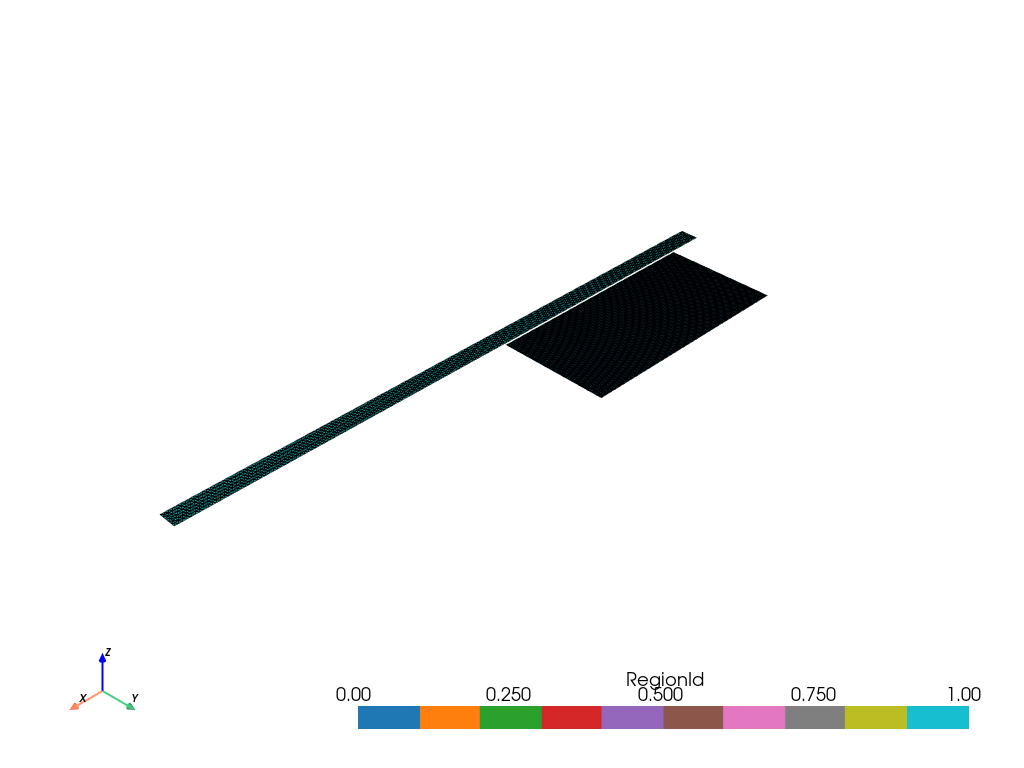

In [6]:
# Connected block labels. In VS Code/Jupyter this should render inline.
grid.plot(scalars="RegionId", preference="cell", show_edges=True, cmap="tab10", jupyter_backend="static")

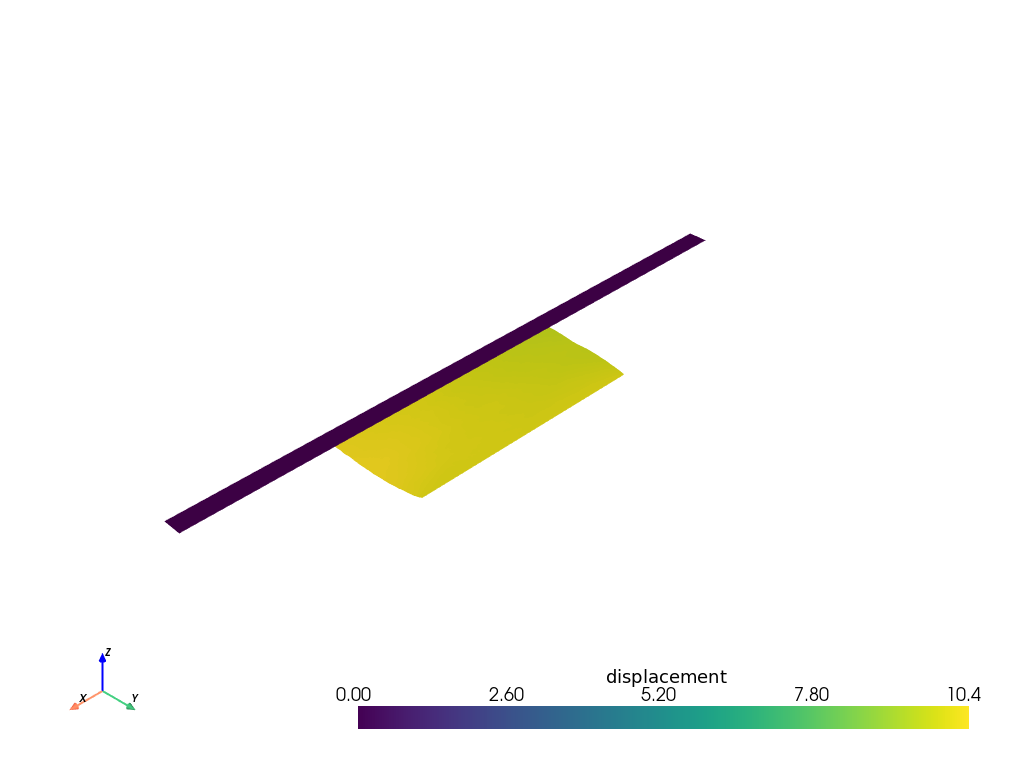

In [7]:
# Deformed shape colored by displacement magnitude.
warped = grid.warp_by_vector("displacement", factor=1.0)
warped["|displacement|"] = np.linalg.norm(warped.point_data["displacement"], axis=1)
warped.plot(scalars="|displacement|", show_edges=False, cmap="viridis", jupyter_backend="static")

## All timesteps

In [8]:
all_summaries = []
for step_path in sorted(PARAVIEW_DIR.glob(PATTERN), key=timestep_number):
    step_grid = read_connected_grid(step_path)
    step_summary = summarize_blocks(
        step_grid,
        point_fields=["displacement", "velocity"],
        cell_fields=["stress"],
    )
    step_summary.insert(0, "step", timestep_number(step_path))
    step_summary.insert(1, "file", step_path.name)
    all_summaries.append(step_summary)

all_steps = pd.concat(all_summaries, ignore_index=True)
all_steps = stress_with_names(all_steps)
all_steps.to_csv(BUILD_DIR / "block_summary_all_steps.csv", index=False)
all_steps.head(10)

,step,file,block,n_points,n_cells,displacement.c0.mean,displacement.c0.min,displacement.c0.max,displacement.c1.mean,displacement.c1.min,displacement.c1.max,displacement.c2.mean,displacement.c2.min,displacement.c2.max,displacement.norm.mean,displacement.norm.min,displacement.norm.max,velocity.c0.mean,velocity.c0.min,velocity.c0.max,velocity.c1.mean,velocity.c1.min,velocity.c1.max,velocity.c2.mean,velocity.c2.min,velocity.c2.max,velocity.norm.mean,velocity.norm.min,velocity.norm.max,stress.c0.mean,stress.c0.min,stress.c0.max,stress.c1.mean,stress.c1.min,stress.c1.max,stress.c2.mean,stress.c2.min,stress.c2.max,stress.c3.mean,stress.c3.min,stress.c3.max,stress.norm.mean,stress.norm.min,stress.norm.max,stress.xx.mean,stress.yy.mean,stress.xy.mean,stress.zz_or_extra.mean
0,0,bloc_friction_test1_0000.pvtu,0,8365,16370,0.000000e+00,0.000000,0.000000,0.000000,0.0000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.0000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
1,0,bloc_friction_test1_0000.pvtu,1,1130,1928,0.000000e+00,0.000000,0.000000,0.000000,0.0000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.0000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
2,1,bloc_friction_test1_0001.pvtu,0,8365,16370,0.000000e+00,0.000000,0.000000,-0.000007,-0.0005,0.000000e+00,0.0,0.0,0.0,0.000007,0.000000e+00,0.0005,-8.753957e-07,-0.663990,0.660480,-0.040034,-4.739961,0.0,0.0,0.0,0.0,0.040064,0.0,4.740077,-1.037029e+07,-9.415353e+08,0.000000e+00,890.942640,-1.478180e+08,1.496331e+08,890.942640,-1.478180e+08,1.496331e+08,-2.419735e+07,-2.196916e+09,0.000000e+00,2.633093e+07,0.000000e+00,2.390173e+09,-1.037029e+07,890.942640,890.942640,-2.419735e+07
3,1,bloc_friction_test1_0001.pvtu,1,1130,1928,0.000000e+00,0.000000,0.000000,0.000000,0.0000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.0000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
4,2,bloc_friction_test1_0002.pvtu,0,8365,16370,3.982427e-07,-0.014197,0.014421,-0.006115,-0.0505,-1.371974e-79,0.0,0.0,0.0,0.006132,1.371974e-79,0.0505,1.040952e-02,-149.780580,153.408518,-49.018342,-291.129906,0.0,0.0,0.0,0.0,49.291592,0.0,319.620423,-9.480351e+08,-5.465575e+09,1.935583e+09,144968.749879,-3.340631e+09,3.392894e+09,144968.749879,-3.340631e+09,3.392894e+09,-2.388544e+09,-1.577288e+10,-3.047289e-65,2.583061e+09,3.315423e-65,1.653245e+10,-9.480351e+08,144968.749879,144968.749879,-2.388544e+09
5,2,bloc_friction_test1_0002.pvtu,1,1130,1928,0.000000e+00,0.000000,0.000000,0.000000,0.0000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.0000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
6,3,bloc_friction_test1_0003.pvtu,0,8365,16370,2.041772e-06,-0.029036,0.028853,-0.023376,-0.1005,-8.711641e-37,0.0,0.0,0.0,0.023507,8.711642e-37,0.1005,-7.066737e-03,-152.905195,154.116236,-98.480703,-297.755373,0.0,0.0,0.0,0.0,99.518011,0.0,334.152462,-1.703074e+09,-5.954974e+09,2.087733e+09,-210880.946161,-4.142876e+09,4.206437e+09,-210880.946161,-4.142876e+0

Text(0, 0.5, 'mean displacement norm')

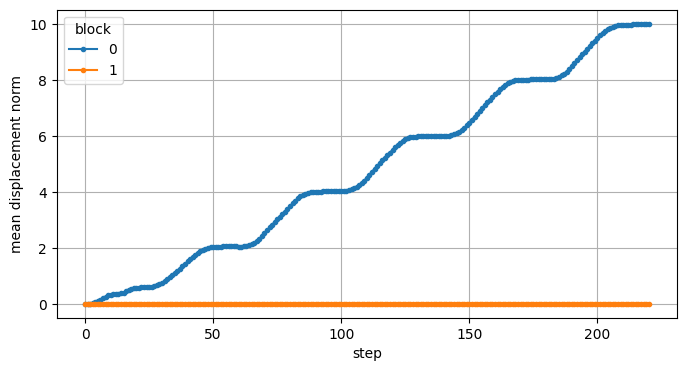

In [9]:
# Quick plot of average displacement norm over time for each block.
ax = all_steps.pivot(index="step", columns="block", values="displacement.norm.mean").plot(
    figsize=(8, 4), marker=".", grid=True
)
ax.set_xlabel("step")
ax.set_ylabel("mean displacement norm")

## Sample three points on block 0

In [10]:
def sample_block_points(grid, block_id=0):
    """Sample top-middle, center, and bottom-middle positions of one connected block."""
    point_region = np.asarray(grid.point_data["RegionId"])
    cell_region = np.asarray(grid.cell_data["RegionId"])

    block_point_ids = np.where(point_region == block_id)[0]
    block_cell_ids = np.where(cell_region == block_id)[0]
    if len(block_point_ids) == 0 or len(block_cell_ids) == 0:
        raise ValueError(f"No data found for block {block_id}")

    block_points = np.asarray(grid.points)[block_point_ids]
    xmin, ymin, zmin = block_points.min(axis=0)
    xmax, ymax, zmax = block_points.max(axis=0)
    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)
    zmid = 0.5 * (zmin + zmax)

    targets = {
        "top_middle": np.array([xmid, ymax, zmid]),
        "center": np.array([xmid, ymid, zmid]),
        "bottom_middle": np.array([xmid, ymin, zmid]),
    }

    cell_centers = np.asarray(grid.cell_centers().points)
    block_cell_centers = cell_centers[block_cell_ids]

    rows = []
    for label, target in targets.items():
        point_distances = np.linalg.norm(block_points - target, axis=1)
        nearest_point_id = int(block_point_ids[np.argmin(point_distances)])

        cell_distances = np.linalg.norm(block_cell_centers - target, axis=1)
        nearest_cell_id = int(block_cell_ids[np.argmin(cell_distances)])

        row = {
            "sample": label,
            "block": block_id,
            "target_x": target[0],
            "target_y": target[1],
            "target_z": target[2],
            "point_id": nearest_point_id,
            "point_x": grid.points[nearest_point_id, 0],
            "point_y": grid.points[nearest_point_id, 1],
            "point_z": grid.points[nearest_point_id, 2],
            "point_distance": float(np.min(point_distances)),
            "cell_id": nearest_cell_id,
            "cell_center_x": cell_centers[nearest_cell_id, 0],
            "cell_center_y": cell_centers[nearest_cell_id, 1],
            "cell_center_z": cell_centers[nearest_cell_id, 2],
            "cell_distance": float(np.min(cell_distances)),
        }

        for name, values in grid.point_data.items():
            if name == "RegionId":
                continue
            value = np.asarray(values[nearest_point_id])
            if value.ndim == 0:
                row[name] = float(value)
            else:
                for component, component_value in enumerate(value):
                    row[f"{name}.c{component}"] = float(component_value)
                row[f"{name}.norm"] = float(np.linalg.norm(value))

        for name, values in grid.cell_data.items():
            if name == "RegionId":
                continue
            value = np.asarray(values[nearest_cell_id])
            if value.ndim == 0:
                row[name] = float(value)
            else:
                for component, component_value in enumerate(value):
                    row[f"{name}.c{component}"] = float(component_value)
                row[f"{name}.norm"] = float(np.linalg.norm(value))

        rows.append(row)

    return pd.DataFrame(rows)


In [11]:
block0_three_points = sample_block_points(grid, block_id=0)
block0_three_points

,sample,block,target_x,target_y,target_z,point_id,point_x,point_y,point_z,point_distance,cell_id,cell_center_x,cell_center_y,cell_center_z,cell_distance,areas,blocked_dofs,contact_force.c0,contact_force.c1,contact_force.c2,contact_force.norm,displacement.c0,displacement.c1,displacement.c2,displacement.norm,external_force.c0,external_force.c1,external_force.c2,external_force.norm,internal_force.c0,internal_force.c1,internal_force.c2,internal_force.norm,normals.c0,normals.c1,normals.c2,normals.norm,tangents.c0,tangents.c1,tangents.c2,tangents.norm,velocity.c0,velocity.c1,velocity.c2,velocity.norm,stress.c0,stress.c1,stress.c2,stress.c3,stress.norm
0,top_middle,0,6.0,7.00,0.0,3995,6.0,7.000000,0.0,1.663736e-11,15363,5.95,6.971132,0.0,0.057735,0.00000,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,10.000000,-1.000000,0.0,10.049876,0.0,0.0,0.0,0.0,-1.425641e+09,4.291232e+09,0.0,4.521850e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,-1.703785e+10,1.202628e+10,1.202628e+10,-3.975498e+10,4.647590e+10
1,center,0,6.0,4.05,0.0,4043,6.0,4.055514,0.0,5.513627e-03,7232,6.00,3.997779,0.0,0.052221,0.00000,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,9.996154,-0.577133,0.0,10.012801,0.0,0.0,0.0,0.0,1.458603e+08,-7.458705e+08,0.0,7.599988e+08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81.358081,-122.024443,0.0,146.659818,-3.105151e+09,1.923765e+09,1.923765e+09,-2.584661e+10,2.617424e+10
2,bottom_middle,0,6.0,1.10,0.0,5210,6.0,1.100000,0.0,2.283418e-11,2717,6.05,1.129549,0.0,0.058079,0.10874,0.0,1.500489e+08,4.665722e+09,0.0,4.668134e+09,9.939453,-0.101073,0.0,9.939967,0.0,0.0,0.0,0.0,-4.465702e+08,-4.636280e+09,0.0,4.657738e+09,0.0,1.0,0.0,1.0,1.0,-0.0,0.0,1.0,-69.944559,4.673335,0.0,70.100509,-1.583013e+09,-1.812667e+09,-1.812667e+09,-5.059385e+10,5.068348e+10


In [12]:
point_summaries = []
for step_path in sorted(PARAVIEW_DIR.glob(PATTERN), key=timestep_number):
    step_grid = read_connected_grid(step_path)
    block0_three_points = sample_block_points(step_grid, block_id=0)
    point_fields = ["displacement.c0", "displacement.c1", "displacement.c2", "displacement.norm",
                     "velocity.c0", "velocity.c1", "velocity.c2",
                    "stress.c0", "stress.c1", "stress.c2", "stress.c3", "stress.norm"]
    for i in range(3):
        point_summaries.append({
            "timestep" : timestep_number(step_path),
            "point" : i,
            "displacement.c0" : block0_three_points["displacement.c0"][i],
            "displacement.c1" : block0_three_points["displacement.c1"][i],
            "displacement.c2" : block0_three_points["displacement.c2"][i],
            "displacement.norm" : block0_three_points["displacement.norm"][i],
            "velocity.c0" : block0_three_points["velocity.c0"][i],
            "velocity.c1" : block0_three_points["velocity.c1"][i],
            "velocity.c2" : block0_three_points["velocity.c2"][i],
            "stress.c0" : block0_three_points["stress.c0"][i],
            "stress.c1" : block0_three_points["stress.c1"][i],
            "stress.c2" : block0_three_points["stress.c2"][i],
            "stress.c3" : block0_three_points["stress.c3"][i],
            "stress.norm" : block0_three_points["stress.norm"][i],
        })
    
points_frame = pd.DataFrame(point_summaries)
#block0_steps = pd.concat(all_summaries, ignore_index=True)
#block0_steps = stress_with_names(block0_steps)
#block0_steps.to_csv(BUILD_DIR / "block_summary_all_steps.csv", index=False)
#block0_steps.head(10)

<Axes: title={'center': 'Displacement Norm Over Time'}, xlabel='timestep'>

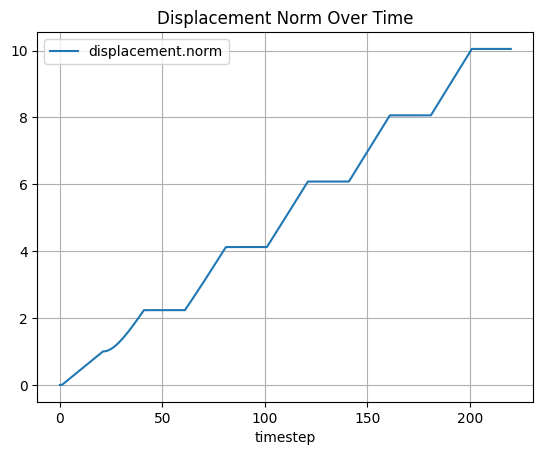

In [13]:
#points_frame.to_csv(BUILD_DIR / "block0_three_points_all_steps.csv", index=False)
points_frame[points_frame["point"] == 0].plot(x="timestep", 
                                              y="displacement.norm", 
                                              title="Displacement Norm Over Time", grid=True)

<Axes: title={'center': 'Point 0 Stress_xx Over Time'}, xlabel='timestep'>

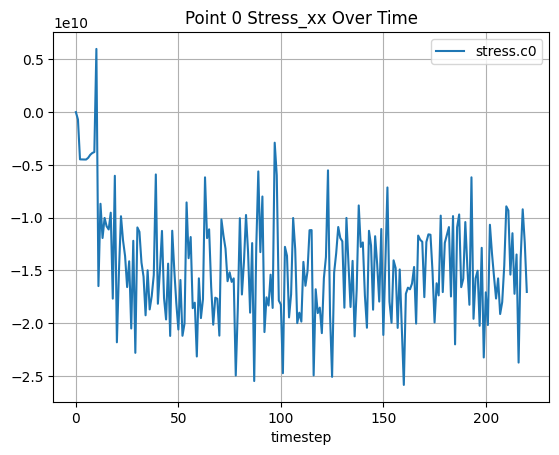

In [14]:
points_frame[points_frame["point"] == 0].plot(x="timestep", 
                                              y="stress.c0", 
                                              title="Point 0 Stress_xx Over Time", grid=True)

<Axes: title={'center': 'Point 1 Stress_xx Over Time'}, xlabel='timestep'>

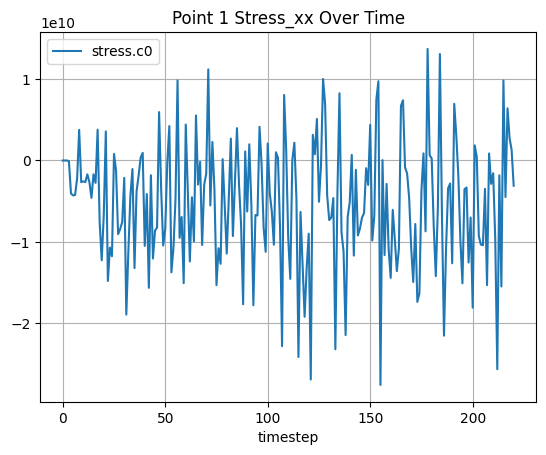

In [15]:
points_frame[points_frame["point"] == 1].plot(x="timestep", 
                                              y="stress.c0", 
                                              title="Point 1 Stress_xx Over Time", grid=True)

<Axes: title={'center': 'Point 2 Stress_xx Over Time'}, xlabel='timestep'>

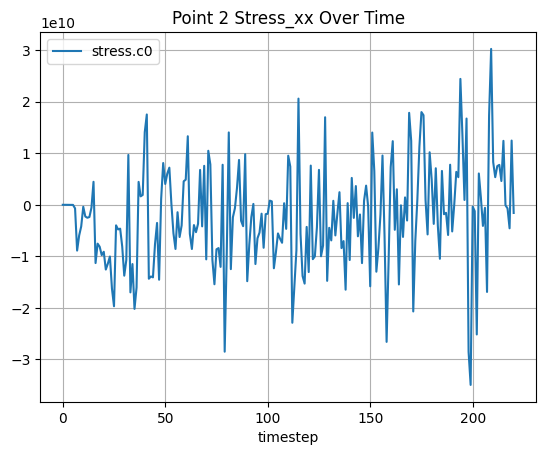

In [16]:
points_frame[points_frame["point"] == 2].plot(x="timestep", 
                                              y="stress.c0", 
                                              title="Point 2 Stress_xx Over Time", grid=True)

## Energies of block 0

Compute and plot elastic strain energy and kinetic energy through time.

In [17]:
RHO = 7800.0       # kg/m^3 from material.dat
THICKNESS = 1.0    # 2D model: energies are per unit out-of-plane thickness


def cell_point_ids(grid):
    """Return a list of point-id arrays, one per cell."""
    cells = np.asarray(grid.cells)
    ids = []
    cursor = 0
    while cursor < len(cells):
        n = int(cells[cursor])
        ids.append(cells[cursor + 1 : cursor + 1 + n].astype(int))
        cursor += n + 1
    return ids


def compute_block_energy(path, block_id=0, rho=RHO, thickness=THICKNESS):
    """Compute approximate kinetic and elastic strain energy for one block."""
    g = read_connected_grid(path)
    g = g.compute_cell_sizes(length=False, area=True, volume=False)
    g = g.compute_derivative(scalars="displacement", gradient="grad_u", preference="point")

    cell_regions = np.asarray(g.cell_data["RegionId"])
    block_cell_mask = cell_regions == block_id
    ids_per_cell = cell_point_ids(g)

    velocity = np.asarray(g.point_data["velocity"])
    grad_u = np.asarray(g.point_data["grad_u"]).reshape(-1, 3, 3)
    stress = np.asarray(g.cell_data["stress"])
    area = np.asarray(g.cell_data["Area"])

    kinetic_energy = 0.0
    elastic_strain_energy = 0.0

    for cell_id, point_ids in enumerate(ids_per_cell):
        if not block_cell_mask[cell_id]:
            continue

        cell_volume = area[cell_id] * thickness

        # K = integral 1/2 rho |v|^2 dV, approximated with nodal mean per cell.
        v2_mean = np.mean(np.sum(velocity[point_ids] ** 2, axis=1))
        kinetic_energy += 0.5 * rho * v2_mean * cell_volume

        # Small strain from displacement gradient, averaged from point gradients to cell.
        grad = np.mean(grad_u[point_ids], axis=0)
        eps_xx = grad[0, 0]
        eps_yy = grad[1, 1]
        gamma_xy = grad[0, 1] + grad[1, 0]

        # Akantu writes four 2D stress components here. Use c0,c1,c2 as xx,yy,xy.
        sig_xx = stress[cell_id, 0]
        sig_yy = stress[cell_id, 3]
        sig_xy = stress[cell_id, 1]
        elastic_density = 0.5 * (sig_xx * eps_xx + sig_yy * eps_yy + sig_xy * gamma_xy)
        elastic_strain_energy += elastic_density * cell_volume

    return {
        "step": timestep_number(path),
        "file": Path(path).name,
        "block": block_id,
        "kinetic_energy": kinetic_energy,
        "elastic_strain_energy": elastic_strain_energy,
    }


block0_energies = pd.DataFrame(
    compute_block_energy(step_path, block_id=0)
    for step_path in sorted(PARAVIEW_DIR.glob(PATTERN), key=timestep_number)
)
block0_energies.to_csv(BUILD_DIR / "block0_energies.csv", index=False)
block0_energies.head()

,step,file,block,kinetic_energy,elastic_strain_energy
0,0,bloc_friction_test1_0000.pvtu,0,0.000000e+00,0.000000e+00
1,1,bloc_friction_test1_0001.pvtu,0,3.060012e+04,3.700397e+06
2,2,bloc_friction_test1_0002.pvtu,0,3.026337e+09,3.057218e+09
3,3,bloc_friction_test1_0003.pvtu,0,6.170801e+09,6.077871e+09
4,4,bloc_friction_test1_0004.pvtu,0,9.315321e+09,9.017866e+09


Text(0.5, 1.0, 'Block 0 energy over time')

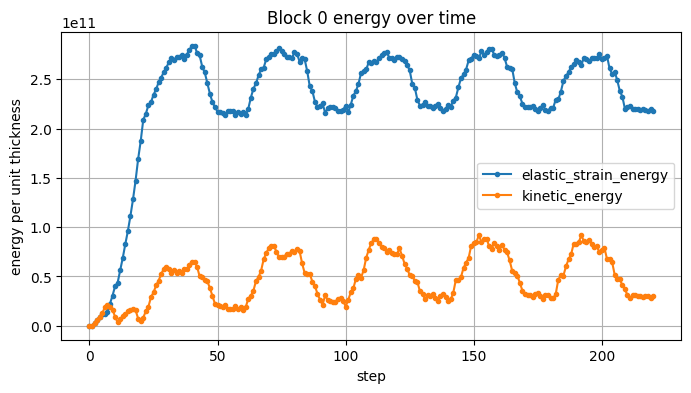

In [18]:
ax = block0_energies.plot(
    x="step",
    y=["elastic_strain_energy", "kinetic_energy"],
    figsize=(8, 4),
    grid=True,
    marker=".",
)
ax.set_xlabel("step")
ax.set_ylabel("energy per unit thickness")
ax.set_title("Block 0 energy over time")